# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Answer: General linear models are easy to use and interpret because they can either be used for a singular probable outcome or be a count for numerical values. Latent variable models are good for predicting stuff that is not as straightforward. It can do nonlinear relationships that aren't as obvious as the normal correlation/association for linear regression..

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Answer: Binary and categorical cross entropy are effective loss functions for fitting logistic regression models because they measure how close predicted probabilities are to the actual values. It penalizes wrong prediction which also matches with the maximizing likelihood.

3. True or false, and explain: Logistic regression is a linear model.

Answer: True because it is just considered a generalized linear model that has weights and stuff similar to a linear model. The main difference is that it just makes it into a curve and not a line.

4. True or false, and explain: Logistic regression cannot be used for classification.

Answer: False because we can still output probabilities and just use the different amounts as category labels.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Answer: No because of log-odds are being changed not tht total predicted probability. It just depends on where you are on the curve. 

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

Answer: False because it still uses a linear equation with inputs so you still need to do feature engineering to get the relationships right.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

Answer: False because logistic regression is only better for classification problems, while ordinary least squares is better for predicting continuous values. You should use the model that fits the type of outcome you have.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [9]:
# 2.1

df2 = pd.read_csv('/workspace/undergrad_ml_assignments/data/data.csv', sep = ';', encoding = 'latin-1')
df2.columns



Index(['ï»¿Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 

In [35]:
focus2 = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df2clean = df2[focus2].copy()
df2clean = df2clean.dropna()
df2clean.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [36]:
y = df2clean['Target']
y = y.replace({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})
X22 = df2clean.drop(['Target', 'Curricular units 1st sem (approved)'], axis=1)


/tmp/ipykernel_2965/1484302374.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})


In [37]:
# 2.2
reg22 = LogisticRegression(penalty=None, max_iter=5000)
reg22.fit(X22, y)
pd.DataFrame({'Variable':reg22.feature_names_in_,'Coefficient':reg22.coef_[0]})

# Higher dropout probability: Debtor, Age of enrollment  
# Lower dropout probability: Tuition fees up to date, Scholarship holder
# Being up to date seems to: reduce drop out risk.

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


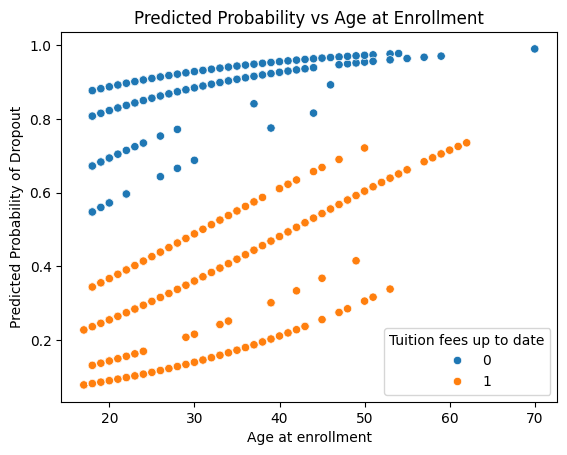

In [ ]:
# 2.3
y_reg23 = reg22.predict_proba(X22)
y_reg23 = [ row[1] for row in y_reg23 ]

plot_df22 = X22.copy()
plot_df22['Dropout'] = y
plot_df22['Predicted Probability'] = y_reg23

sns.scatterplot(data=plot_df22, x='Age at enrollment', y='Predicted Probability', hue='Tuition fees up to date')
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted Probability of Dropout')
plt.title('Predicted Probability vs Age at Enrollment')
plt.show()

# Ages between 18-25 seem to reduce dropout probability the most
# On average, being up to date on tuition reduces the predicted proabability of dropout by around 0.2-0.3

In [44]:
# 2.4
y_class24 = reg22.predict(X22)
tab24 = pd.crosstab(y_class24, y)
acc24 = np.trace(tab24) / len(y_class24)
print(f'Confusion matrix:\n {tab24}')
print(f'\nAccuracy: {acc24}')

Confusion matrix:
 Target     0    1
row_0            
0       2841  891
1        162  530

Accuracy: 0.7619801084990958


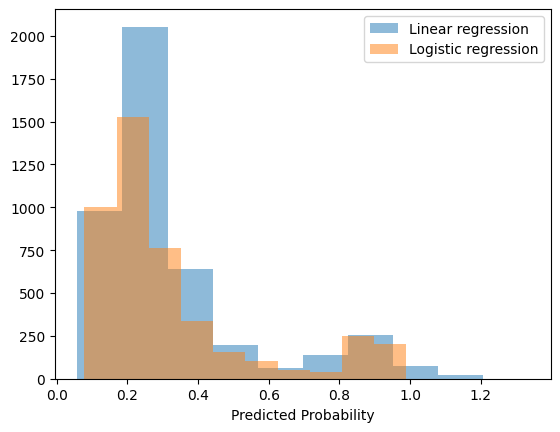

In [50]:
# 2.5 
model25 = LinearRegression()
model25.fit(X22, y)
y_pred25 = model25.predict(X22)

y_logit = reg22.predict_proba(X22)[:, 1]

plt.hist(x=y_pred25, alpha=0.5, label='Linear regression')
plt.hist(x=y_logit, alpha=0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

# Logistic regression is better because it fits between 0-1.

# 2.6

Students who are older, their tuition isn't up to date, and they don't hold scholarships are the most at-risk of dropping out. Interventions include giving them financial aid and then giving them a potion to reverse aging effects (this is a joke I'm tired).

In [51]:
# 2.6
X26 = df2clean.drop(['Target'], axis=1)
reg26 = LogisticRegression(penalty=None, max_iter=5000)
reg26.fit(X26, y)
pd.DataFrame({'Variable':reg26.feature_names_in_,'Coefficient':reg26.coef_[0]})

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.530334
1,Tuition fees up to date,-2.468833
2,Scholarship holder,-0.944699
3,Age at enrollment,0.057069
4,Curricular units 1st sem (approved),-0.429763


In [55]:
reg26.predict(X26)
pd.crosstab(y, reg26.predict(X26))

# Results: The model is pretty good at predicting dropouts, but not as good at predicting graduates and enrolled students. 
# The hard classification using .predict() does not predict every class, since it only predicts two classes and misses one category.

col_0,0,1
Target,,
0,2752,251
1,482,939


In [56]:
reg26.predict_proba(X26)
pd.DataFrame(reg26.predict_proba(X26))

# It does.

,0,1
0,0.339261,0.660739
1,0.377594,0.622406
2,0.044009,0.955991
3,0.871242,0.128758
4,0.513871,0.486129
...,...,...
4419,0.823362,0.176638
4420,0.274275,0.725725
4421,0.937950,0.062050
4422,0.918858,0.081142


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [8]:
# 3.1

df3 = pd.read_csv('/workspace/undergrad_ml_assignments/data/cirrhosis.csv', encoding = 'latin-1')
df3.columns
focus3 = ['Bilirubin', 'Edema','Drug', 'Stage','Status']
df3clean = df3[focus3].copy()
df3clean = df3clean.dropna()
df3clean.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
# 3.2
X32 = df3clean.drop(['Status', 'Stage'], axis=1)
X32 = pd.get_dummies(X32, columns=['Edema', 'Drug'], drop_first=True)

y32 = df3clean['Status']
y32 = y32.replace({'D': 1, 'C': 0, 'CL': 0})

reg32 = LogisticRegression(penalty=None, max_iter=5000)
reg32.fit(X32, y32)

pd.DataFrame({'Variable': reg32.feature_names_in_, 'Coefficient': reg32.coef_[0]})

# Does the drug improve survival probability? The drug does not improve survival probabilitiy.
# Does higher or lower bilirubin predict a higher or lower survival rate? Higher bilirubin predicts a lower survival rate
# How does survival rate vary with edema? Survival rate also decreases with edema, as higher levels of edema increase the probability of death.

/tmp/ipykernel_1835/279285017.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y32 = y32.replace({'D': 1, 'C': 0, 'CL': 0})
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,0.350381
1,Edema_S,0.578551
2,Edema_Y,2.859322
3,Drug_Placebo,-0.252657


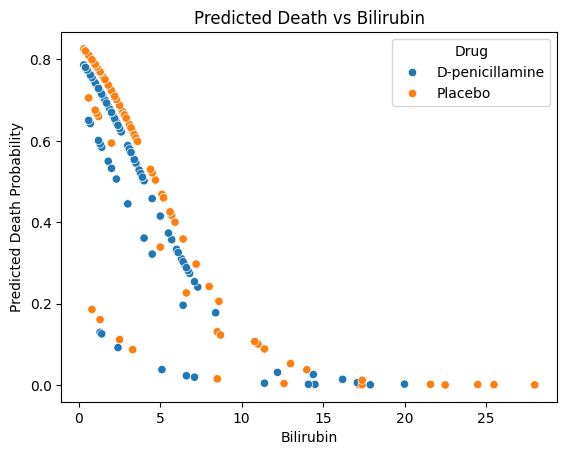

In [22]:
# 3.3

sns.scatterplot(
    data=df3clean,
    x='Bilirubin',
    y=reg32.predict_proba(X32)[:, 0], # computed probabilities of survival
    hue='Drug'
)
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Death Probability')
plt.title('Predicted Death vs Bilirubin')
plt.show()

In [23]:
df3clean['Survival'] = reg32.predict_proba(X32)[:, 0]

df3clean.groupby('Drug')['Survival'].mean()

# For what values of `Bilirubin` does the drug seem to increase patient survival rate? 
# - It does not seem to increase at any level of bilirubin
# On average, by how much do patients who take the drug increase their probability of survival?
# - On average, patients who take the drug decrease their probability of survival by like 0.02.

Drug
D-penicillamine    0.588616
Placebo            0.610393
Name: Survival, dtype: float64

In [24]:
y_survival = reg32.predict_proba(X32)[:, 0]
y_survival

array([1.45537042e-03, 7.35633120e-01, 5.84124565e-01, 5.49729032e-01,
       6.15424765e-01, 7.99178003e-01, 7.87695245e-01, 8.25829761e-01,
       5.71406720e-01, 3.63807040e-03, 7.63314154e-01, 5.98710964e-01,
       8.04742462e-01, 1.85705922e-01, 7.55563466e-01, 8.04742462e-01,
       6.71602131e-01, 4.29989198e-03, 6.42216040e-01, 4.68672334e-01,
       8.10189358e-01, 5.54165748e-01, 6.78811785e-04, 6.62177342e-01,
       8.04742462e-01, 4.59957644e-01, 1.52335124e-03, 7.28050847e-04,
       8.04742462e-01, 5.98710964e-01, 5.03669312e-01, 7.37067751e-01,
       7.99178003e-01, 7.55563466e-01, 7.75740159e-01, 8.25829761e-01,
       1.91106027e-02, 6.23683245e-01, 7.61976484e-01, 7.21781846e-01,
       2.74127707e-01, 7.16195798e-01, 7.35633120e-01, 8.67395947e-02,
       8.10189358e-01, 3.57011114e-01, 8.15519141e-01, 7.30221230e-01,
       7.99178003e-01, 7.35633120e-01, 7.99178003e-01, 3.33260503e-01,
       6.21947276e-01, 1.29430382e-01, 6.85276242e-01, 7.81776712e-01,
      

In [27]:
# 3.4
y_class34 = reg32.predict(X32)
tab34 = pd.crosstab(y_class34, y32)
acc34 = np.trace(tab34) / len(y_class34)
print(f'Confusion matrix:\n {tab34}')
print(f'\nAccuracy: {acc34}')



Confusion matrix:
 Status    0   1
row_0          
0       173  68
1        14  57

Accuracy: 0.7371794871794872


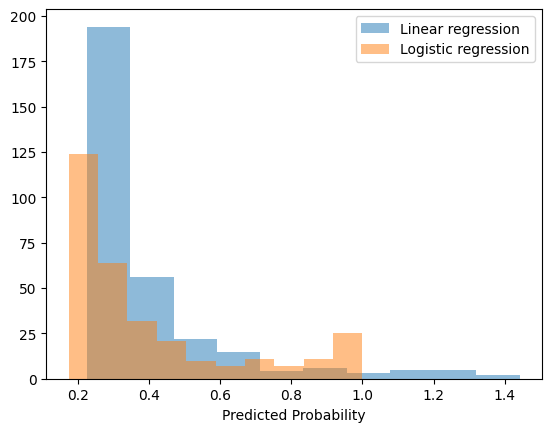

In [29]:
# 3.5
model35 = LinearRegression()
model35.fit(X32, y32)
y_pred35 = model35.predict(X32)

y_logit = reg32.predict_proba(X32)[:, 1]

plt.hist(x=y_pred35, alpha=0.5, label='Linear regression')
plt.hist(x=y_logit, alpha=0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

# Logistic regression is better because it fits between 0-1. Linear regression is not appropriate for binary classification problems, as it can predict values outside the range of 0 and 1, which do not make sense for probabilities. 
# Logistic regression, on the other hand, models the log-odds of the probability and ensures that the predicted probabilities are always between 0 and 1.

In [35]:
# 3.6
X36 = df3clean[['Edema', 'Bilirubin']].copy()
X36 = pd.get_dummies(X36, columns=['Edema'], drop_first=True)
y36 = df3clean['Stage']

reg36 = LogisticRegression(penalty=None, max_iter=5000)
reg36.fit(X36, y36)
pd.DataFrame({'Variable':reg36.feature_names_in_,'Coefficient':reg36.coef_[0]})


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,-0.442466
1,Edema_S,-9.386223
2,Edema_Y,-4.528588


In [37]:
y_class36 = reg36.predict(X36)
pd.crosstab(y36, y_class36)
acc36 = np.trace(tab36) / len(y_class36)
print(f'Confusion matrix:\n {tab36}')
print(f'\nAccuracy: {acc36}')

Confusion matrix:
 Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     16   61  102   74
4.0      0    6   18   35

Accuracy: 0.07051282051282051


In [39]:
pd.DataFrame(reg36.predict_proba(X36))

# The hard classification using .predict() does not predict every class, since some classes are not selected as the final prediction. However, the predicted probabilities from .predict_proba() do include every class, as each observation has a probability for all possible classes.

,0,1,2,3
0,2.965432e-08,0.022548,0.124085,0.853367
1,7.611339e-02,0.252747,0.397286,0.273854
2,2.405392e-07,0.175629,0.404098,0.420273
3,1.887830e-07,0.170141,0.403070,0.426790
4,2.053819e-02,0.228845,0.425472,0.325145
...,...,...,...,...
307,1.108591e-01,0.254674,0.380373,0.254094
308,1.108591e-01,0.254674,0.380373,0.254094
309,5.456138e-02,0.248464,0.408039,0.288936
310,4.606378e-02,0.245648,0.412347,0.295941


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

# ANSWER IN PDF